In [18]:
import pandas as pd
df = pd.read_csv('C:/Users/RUDRAKSHI/Downloads/train.csv/train.csv', encoding='latin1')

In [19]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [20]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [22]:
df['Order Date'].head(10)

0    08/11/2017
1    08/11/2017
2    12/06/2017
3    11/10/2016
4    11/10/2016
5    09/06/2015
6    09/06/2015
7    09/06/2015
8    09/06/2015
9    09/06/2015
Name: Order Date, dtype: object

In [23]:
df = df.drop_duplicates()

In [25]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [26]:
print(df['Sales'].sum())

2261536.7827000003


In [27]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64

In [29]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')

In [30]:
print(df['Order Date'].dtype)

datetime64[ns]


In [31]:
df.groupby(df['Order Date'].dt.month)['Sales'].sum()

Order Date
1     155990.9154
2     131153.2594
3     212256.1344
4     142984.2481
5     166000.7467
6     142034.7713
7     159472.5865
8     207601.7939
9     245155.0671
10    183851.9562
11    268768.7885
12    246266.5152
Name: Sales, dtype: float64

In [32]:
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

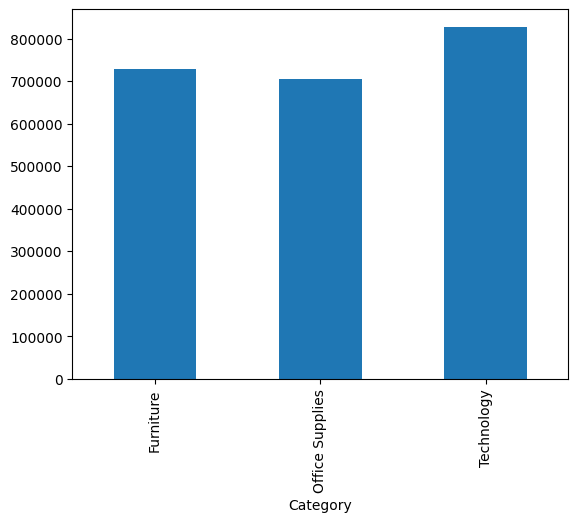

In [33]:
import matplotlib.pyplot as plt
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.show()

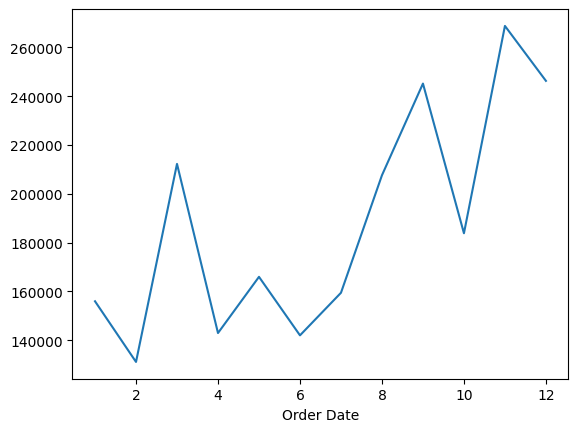

In [34]:
df.groupby(df['Order Date'].dt.month)['Sales'].sum().plot(kind='line')
plt.show()

Based on your actual outputs, here are 3 solid, numbers-backed insights:
Insight 1 — Technology drives the most revenue
From your bar chart (groupby('Category')):

Technology is the top-performing category, generating roughly $830,000 in sales — ahead of Furniture (~$730,000) and Office Supplies (~$700,000). At the sub-category level, Phones ($327,782) and Chairs ($322,822) are the two highest revenue generators individually. This suggests the business should prioritize inventory and marketing investment in Technology and Furniture's top sub-categories, since they're carrying a disproportionate share of revenue.

Insight 2 — Sales are highly seasonal, peaking at year-end
From your line chart (groupby(Order Date.dt.month)):

Sales show a strong seasonal pattern, peaking sharply in November ($268,768) and December ($246,266) — likely driven by holiday shopping and year-end business purchasing. In contrast, February is the weakest month ($131,153), less than half of November's total. This means the business should plan inventory stock-up and marketing campaigns ahead of Q4, while considering promotions in Q1 (especially February) to smooth out the slow period.

Insight 3 — Revenue is concentrated in a small group of top customers
From your groupby('Customer Name') output:

The top customer, Sean Miller, alone contributes $25,043 in sales, with the top 10 customers (including Tamara Chand at $19,052 and Raymond Buch at $15,117) together driving a significant chunk of total revenue. This concentration means the business is somewhat dependent on a small number of high-value customers — losing even one or two of them could noticeably impact revenue, so a customer retention/loyalty strategy for this segment would reduce that risk.